In [22]:
import pandas as pd

In [23]:
df = pd.read_csv("ABCP_xdeepAcpep_predictions.csv",index_col=0)
df = df[(df["ProtBERT_prediction"]==1) & (df["ESM_prediction"] ==1)]
df.reset_index()
df.head()
df.shape

(260549, 9)

In [24]:
df.columns = ['Sequence_ID', 'Sequence', 'ProtBERT_nonABCP_probability',
       'ProtBERT_ABCP_probability', 'ProtBERT_prediction',
       'ESM_nonABCP_probability', 'ESM_ABCP_probability', 'ESM_prediction',
       'IC50 (micromolar)']

In [25]:
df.head()

,Sequence_ID,Sequence,ProtBERT_nonABCP_probability,ProtBERT_ABCP_probability,ProtBERT_prediction,ESM_nonABCP_probability,ESM_ABCP_probability,ESM_prediction,IC50 (micromolar)
25,PAp00002355,FDAGELITQR,0.008981,0.991019,1,0.175908,0.824092,1,562.468221
28,PAp00002489,FLILPDMLK,0.138991,0.861009,1,0.019285,0.980715,1,109.259763
43,PAp00003182,GVVDSEDIPLNLSR,0.020888,0.979112,1,0.323065,0.676935,1,376.493931
54,PAp00003640,HYGGLTGLNK,0.297571,0.702429,1,0.280858,0.719142,1,499.438796
77,PAp00004802,LDLAGRDLTDYLMK,0.254087,0.745913,1,0.109668,0.890332,1,177.335234


In [26]:
df["IC50 (Molar)"] = df["IC50 (micromolar)"] * 1e-6

In [27]:
df.head()

,Sequence_ID,Sequence,ProtBERT_nonABCP_probability,ProtBERT_ABCP_probability,ProtBERT_prediction,ESM_nonABCP_probability,ESM_ABCP_probability,ESM_prediction,IC50 (micromolar),IC50 (Molar)
25,PAp00002355,FDAGELITQR,0.008981,0.991019,1,0.175908,0.824092,1,562.468221,0.000562
28,PAp00002489,FLILPDMLK,0.138991,0.861009,1,0.019285,0.980715,1,109.259763,0.000109
43,PAp00003182,GVVDSEDIPLNLSR,0.020888,0.979112,1,0.323065,0.676935,1,376.493931,0.000376
54,PAp00003640,HYGGLTGLNK,0.297571,0.702429,1,0.280858,0.719142,1,499.438796,0.000499
77,PAp00004802,LDLAGRDLTDYLMK,0.254087,0.745913,1,0.109668,0.890332,1,177.335234,0.000177


In [28]:
df = df[(df["ProtBERT_ABCP_probability"] >= 0.7) | (df["ESM_ABCP_probability"] >= 0.7)]

In [29]:
df.shape

(256889, 10)

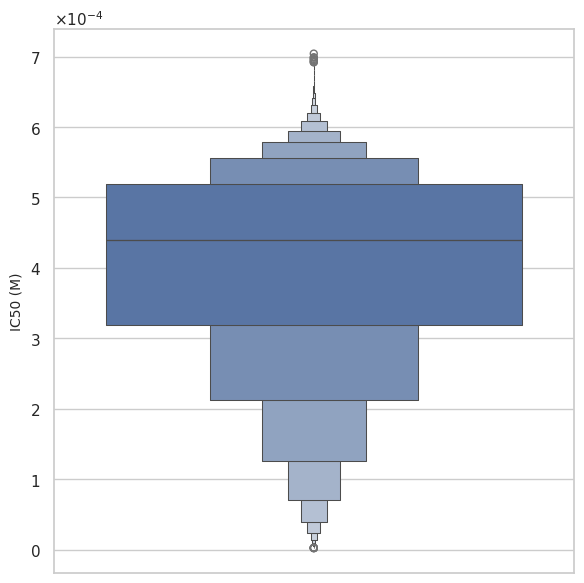

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

sns.set(style="whitegrid")

plt.figure(figsize=(6,6))
sns.boxenplot(y=df["IC50 (Molar)"])

# Force scientific notation like 1e-3
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((0, 0))  # always use scientific notation

ax = plt.gca()
ax.yaxis.set_major_formatter(formatter)

plt.ylabel("IC50 (M)", fontsize=10)
plt.tight_layout()
plt.savefig("Predicted_ic50.tiff", dpi=300)
plt.show()